<a href="https://colab.research.google.com/github/Varsini09/Agentic-AI---Educational-Coach/blob/main/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow pandas numpy matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
uploaded = files.upload()
FILE_NAME = "Reviews.csv"
df = pd.read_csv(FILE_NAME)
df.head()

KeyboardInterrupt: 

Sample Dataset:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Total Words: 12633
Total Sequences: 171312
Maximum Sequence Length: 16
(171312, 15)
(171312,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 100)        │     1,263,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12633)          │     1,907,583 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,321,483 (12.67 MB)

 Trainable params: 3,321,483 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 208s 152ms/step - accuracy: 0.0389 - loss: 6.8462
Epoch 2/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 263s 153ms/step - accuracy: 0.0707 - loss: 6.3086
Epoch 3/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 268s 157ms/step - accuracy: 0.0908 - loss: 5.9960
Epoch 4/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 204s 152ms/step - accuracy: 0.1010 - loss: 5.7654
Epoch 5/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 201s 150ms/step - accuracy: 0.1105 - loss: 5.5587
Epoch 6/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 201s 150ms/step - accuracy: 0.1185 - loss: 5.3650
Epoch 7/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 200s 148ms/step - accuracy: 0.1260 - loss: 5.1828
Epoch 8/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 197s 147ms/step - accuracy: 0.1333 - loss: 5.0095
Epoch 9/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 198s 148ms/step - accuracy: 0.1419 - loss: 4.8449
Epoch 10/10
1339/1339 ━━━━━━━━━━━━━━━━━━━━ 204s 149ms/step - accuracy: 0.1523 - loss: 4.6899


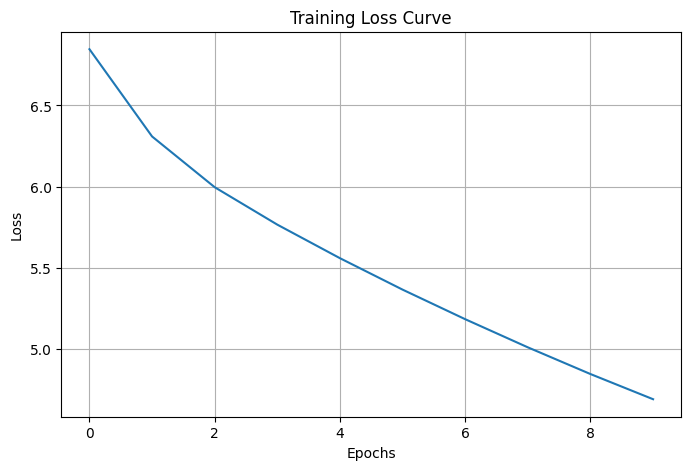

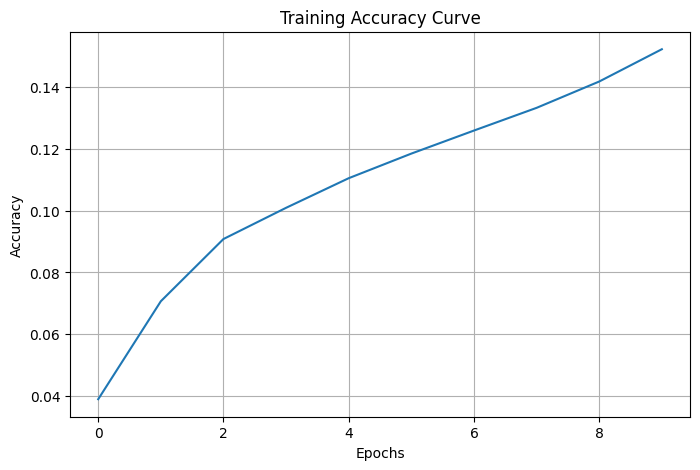


Input Text: First Citizen
Predicted Next Word: to


In [ ]:
# Install TensorFlow
!pip install tensorflow

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


# ==============================
# Load Shakespeare Dataset
# ==============================

path_to_file = tf.keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

with open(path_to_file, "r", encoding="utf-8") as f:
    text = f.read()


print("Sample Dataset:\n")
print(text[:500])


# ==============================
# Tokenization
# ==============================

tokenizer = Tokenizer()

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1


print("\nTotal Words:", total_words)



# ==============================
# Create N-Gram Sequences
# ==============================

input_sequences = []


for line in text.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_sequence = token_list[:i+1]

        input_sequences.append(n_gram_sequence)



print("Total Sequences:", len(input_sequences))


# Padding

max_sequence_len = max(
    [len(x) for x in input_sequences]
)


input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding='pre'
    )
)


print("Maximum Sequence Length:", max_sequence_len)



# ==============================
# Split Input and Output
# ==============================

X = input_sequences[:, :-1]

y = input_sequences[:, -1]


print(X.shape)
print(y.shape)



# ==============================
# Build LSTM Model
# ==============================

model = Sequential()

model.add(
    tf.keras.Input(
        shape=(max_sequence_len-1,)
    )
)

model.add(
    Embedding(
        input_dim=total_words,
        output_dim=100
    )
)

model.add(
    LSTM(150)
)

model.add(
    Dense(
        total_words,
        activation='softmax'
    )
)

model.summary()



# ==============================
# Compile Model
# ==============================

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)



# ==============================
# Train Model
# ==============================

history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=128
)



# ==============================
# Training Loss Curve
# ==============================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.title("Training Loss Curve")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.grid(True)

plt.show()



# ==============================
# Training Accuracy Curve
# ==============================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.title("Training Accuracy Curve")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()



# ==============================
# Predict Next Word Function
# ==============================


def predict_next_word(seed_text):

    token_list = tokenizer.texts_to_sequences(
        [seed_text]
    )[0]


    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding='pre'
    )


    predicted = np.argmax(
        model.predict(token_list, verbose=0)
    )


    for word, index in tokenizer.word_index.items():

        if index == predicted:

            return word



# ==============================
# Test Prediction
# ==============================


input_text = "First Citizen"


next_word = predict_next_word(input_text)


print("\nInput Text:", input_text)

print("Predicted Next Word:", next_word)